# Warm Glow Bequest Motives

The base assumption in consumption-saving models is that "you can't take it with you": wealth is only valuable because it can be consumed within one's own lifetime, yielding utility flows. A fairly common alternative assumption is that wealth has a *terminal value*, so that agents derive utility from holding assets at the moment of their passing. This is often used to model agents with a bequest motive, who actively plan to leave an estate for their heirs. Because the utility from the bequest motive is only experienced at the end of life, it is known as a "warm glow"-- one final dose of happiness.

The module `HARK.ConsumptionSaving.ConsBequestModel` has `AgentType` subclasses with this model feature; this notebook covers `BequestWarmGlowConsumerType`, which extends the workhorse `IndShockConsumerType`.

In [1]:
# Initial imports and notebook setup
import matplotlib.pyplot as plt
import numpy as np
from time import time

from HARK.models import IndShockConsumerType, BequestWarmGlowConsumerType
from HARK.ConsumptionSaving.ConsBequestModel import init_warm_glow
from HARK.Calibration.Income.IncomeTools import (
    Cagetti_income,
    parse_income_spec,
    parse_time_params,
)
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table

mystr = lambda number: f"{number:.4f}"

## Statement of Consumption-Saving Model with a Warm Glow Bequest Motive

$\newcommand{\CRRA}{\rho}$
$\newcommand{\LivPrb}{\mathsf{S}}$
$\newcommand{\PermGroFac}{\Gamma}$
$\newcommand{\Rfree}{\mathsf{R}}$
$\newcommand{\DiscFac}{\beta}$
$\newcommand{\BeqShift}{\xi}$
$\newcommand{\BeqFac}{\alpha}$

The model for a `BequestConsumerType` is essentially identical to that of `IndShockConsumerType`, but with an additional term for the warm glow bequest motive. The warm glow uses the same utility function as ordinary consumption, with a shifter $\BeqShift$ and scaling factor $\BeqFac$. It can be expressed in Bellman form as:

\begin{align*}
\text{v}_t(m_t) &= \max_{c_t} \frac{c_t^{1-\CRRA}}{1-\CRRA} + \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1}\psi_{t+1})^{1-\CRRA} \text{v}_{t+1}(m_{t+1}) \right] + (1-\LivPrb_t) \BeqFac \frac{(a_t + \BeqShift)^{1-\CRRA}}{1-\CRRA} \\
&\text{s.t.} \\
a_t &= m_t - c_t, \\
a_t &\geq \text{$\underline{a}$}, \\
m_{t+1} &= \Rfree_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) a_t + \theta_{t+1}, \\
(\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}, \\
\mathbb{E}[\psi]&= 1. \\
\end{align*}

That is, the agent chooses their consumption to optimize the sum of current flow utility and the value of retained assets. In this context, assets yield value whether the agent survives to period $t+1$ (probability $\LivPrb_t$) or dies before then (probability $1-\LivPrb_t$ term. Retained assets yield risk free interest at factor $\Rfree_{t+1}$, and future income is subject to permanent and transitory shocks.

## Solving the Warm Glow Bequest Model

Like almost all models in HARK, the `BequestWarmGlowConsumerType`'s problem can be solved using the endogenous grid method. The end-of-period value function over assets $a_t$ now includes two terms:

\begin{align*}
\mathfrak{v}_t(a_t) &\equiv \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1}\psi_{t+1})^{1-\CRRA} \text{v}_{t+1}(m_{t+1}) \right] + (1-\LivPrb_t) \BeqFac \frac{(a_t + \BeqShift)^{1-\rho}}{1-\rho} \\
&\text{s.t.} \\
m_{t+1} &= \Rfree_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) a_t + \theta_{t+1}, \\
(\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}. \\
\end{align*}

Likewise, the marginal value of end-of-period assets is:

\begin{equation*}
\mathfrak{v}'_t(a_t) = \DiscFac \LivPrb_t \Rfree_{t+1} \mathbb{E}_{t} \left[ (\PermGroFac_{t+1}\psi_{t+1})^{-\CRRA} \text{v}'_{t+1}(m_{t+1}) \right] + (1-\LivPrb_t) \BeqFac (a_t + \BeqShift)^{-\CRRA}.
\end{equation*}

Just like the basic consumption-saving model, the end-of-period value function can be substiuted into the Bellman problem:

\begin{align*}
\text{v}_t(m_t) &= \max_{c_t} \frac{c_t^{1-\CRRA}}{1-\CRRA} + \mathfrak{v}_t(a_t) \\
&\text{s.t.} \\
a_t &= m_t - c_t, \\
a_t &\geq \text{$\underline{a}$}. \\
\end{align*}

There is thus one first order condition for an optimal interior solution, the usual:

\begin{equation*}
c_t^{-\CRRA} - \mathfrak{v}'_t(a_t) = 0 \Longrightarrow c_t = \mathfrak{v}'_t(a_t)^{-1/\CRRA}.
\end{equation*}

The (unconstrained) consumption function for period $t$ can thus be constructed following the usual steps:

1. Choose an exogenous grid of assets $a_t$
2. Evaluate expected marginal value of end-of-period assets $\mathfrak{v}'_t(a_t)$ for each gridpoint
3. Find the associated optimal consumption $c_t$ using the FOC
4. Recover the endogenous market resources gridpoints as $m_t = a_t + c_t$
5. Interpolate over $(m_t, c_t)$ points on the consumption function

## A Small Re-Parameterization

The "bequest scale" $\BeqFac$ and "bequest shifter" $\BeqShift$ parameters look easy to interpret, but it turns out they're not. E.g. if y $\alpha = 50$ for some agent, would this be a "strong" or "weak" bequest motive? It turns out that the answer is "it depends." Let's investigate.

In the terminal period, $\LivPrb_T = 0$ because there is no future; death is certain. So the marginal value of end-of-period assets is simply $\mathfrak{v}_T(a_T) = (1-0) \BeqFac (a_t + \BeqShift)^{-\CRRA}$. Using this in the EGM-style first order condition, we can find the terminal period's (unconstrained) consumption function:

\begin{equation*}
c_T = \mathfrak{v}_T(a_T)^{-1/\CRRA} = \BeqFac^{-1/\CRRA} (a_T + \BeqShift) = \BeqFac^{-1/\CRRA} a_T + \BeqShift / \BeqFac^{1/\CRRA}.
\end{equation*}

The marginal propensity to consume in the terminal period (when not constrained by $a_T \geq 0$) is thus $\BeqFac^{-1/\CRRA}$. If $\CRRA = 2$, then the MPC is about $0.14$. If instead $\CRRA = 3$, the terminal MPC is over $0.27$; with log utility ($\CRRA = 1$), it would be a mere $0.02$. The bequest scaling factor $\BeqFac$ isn't informative or interpretable *on its own* with respect to terminal period behavior.

More generally, recall that the envelope condition for consumption-saving models (including this one) says that the marginal value of market resources equals the marginal utility of (optimal) consumption at that point: $\text{v}'_t(m_t) = u'(c_t) = c_t^{-\CRRA}$. Optimal consumption is attained by matching marginal utility of consumption today to (expected discounted) marginal utility of consumption tomorrow.

We can thus mathematically interpret warm glow bequest motive as "mixing in" additional future consumption realizations with probability $1-\LivPrb_t$ by rearranging the bequest motive to "look like" a consumption function:

\begin{equation*}
\BeqFac (a_t + \BeqShift)^{-\CRRA} = \left( \BeqFac^{-1/\CRRA} \right)^{-\CRRA} (a_t + \BeqShift)^{-\CRRA} = (\BeqFac^{-1/\CRRA} a_t + \BeqShift / \BeqFac^{1/\CRRA})^{-1/\CRRA}.
\end{equation*}

This is the same as the closed form for terminal period (unconstrained) consumption. The warm glow bequest motive is *mathematically equivalent to* mixing in future consumption realizations of $\BeqFac^{-1/\CRRA} a_t + \BeqShift / \BeqFac^{1/\CRRA}$ at the probability of death.

For the purposes of parameterizing the model, we define the "bequest MPC" $\gamma \equiv \BeqFac^{-1/\CRRA}$ and the "bequest intercept" $\kappa = \gamma \BeqShift$. These somewhat more interpretable parameters are passed as raw values to `BequestConsumerType`, which then translates them into $\BeqFac$ and $\BeqShift$.

## Example Parameters for `BequestWarmGlowConsumerType`

The default parameters for `BequestWarmGlowConsumerType` are mostly identical to those of `IndShockConsumerType`, but for the addition of `BeqMPC` and `BeqInt`.

| Parameter | Description | Code | Value | Time-varying? |
| :---: | --- | --- | --- | --- |
| $\DiscFac$ |Intertemporal discount factor  | `DiscFac` | $0.96$ |  |
| $\CRRA$ | Coefficient of relative risk aversion | `CRRA` | $2.0$ | |
| $\gamma$ | Marginal propensity to consume in terminal period | `BeqMPC`| $0.2$ |  |
| $\kappa$ | Consumption function intercept term in terminal period | `BeqInt`| $0.1$ |  |
| $\Rfree_t$ | Risk free interest factor | `Rfree` | $[1.03]$ | $\surd$ |
| $\LivPrb_t$ |Survival probability | `LivPrb` | $[0.98]$ | $\surd$ |
| $\PermGroFac_{t}$ |Permanent income growth factor| `PermGroFac` | $[1.01]$ | $\surd$ |
| $\sigma_\psi$ | Standard deviation of log permanent income shocks | `PermShkStd` | $[0.1]$ |$\surd$ |
| $N_\psi$ | Number of discrete permanent income shocks | `PermShkCount` | $7$ | |
| $\sigma_\theta$ | Standard deviation of log transitory income shocks | `TranShkStd` | $[0.1]$ | $\surd$ |
| $N_\theta$| Number of discrete transitory income shocks | `TranShkCount` | $7$ |  |
| $\mho$ | Probability of being unemployed and getting $\theta=\underline{\theta}$ | `UnempPrb` | $0.05$ |  |
| $\underline{\theta}$| Transitory shock when unemployed | `IncUnemp` | $0.3$ |  |
| $\mho^{Ret}$ | Probability of being "unemployed" when retired | `UnempPrbRet` | $0.0005$ |  |
| $\underline{\theta}^{Ret}$| Transitory shock when "unemployed" and retired | `IncUnempRet` | $0.0$ |  |
| $(none)$ | Period of the lifecycle model when retirement begins | `T_retire` | $0$ | |
| $(none)$ | Minimum value in assets-above-minimum grid | `aXtraMin` | $0.001$ | |
| $(none)$ | Maximum value in assets-above-minimum grid | `aXtraMax` | $20.0$ | |
| $(none)$ | Number of points in base assets-above-minimum grid | `aXtraCount` | $48$ | |
| $(none)$ | Exponential nesting factor for base assets-above-minimum grid | `aXtraNestFac` | $3$ | |
| $(none)$ | Additional values to add to assets-above-minimum grid | `aXtraExtra` | $None$ | |
| $\underline{a}$| Artificial borrowing constraint (normalized) | `BoroCnstArt` | $0.0$ | |
| $(none)$|Indicator for whether `vFunc` should be computed | `vFuncBool` | $True$ | |
| $(none)$ |Indicator for whether `cFunc` should use cubic splines | `CubicBool` | $False$ |  |

The parameter transformation can be turned off by passing `constructors["BeqFac"] = None` and `constructors["BeqShift"] = None` to the instantiator for `BequestConsumerType`.

## Example Implementation of Warm Glow Bequest Model

In an infinite horizon setting, the consumption function for an agent with a warm glow bequest motive will differ little from an (otherwise identical) agent without one. When the probability of death is small, "mixing in" additional finite consumption realizations has a relatively small effect. Thus to gauge the effect of the bequest motive, we'll use a life-cycle calibration.

In [2]:
# Define a life-cycle calibration using HARK tools
birth_age = 22
death_age = 110
adjust_infl_to = 1992
income_calib = Cagetti_income["College"]
income_calib["PermShkStd"] = 0.1
income_calib["TranShkStd"] = 0.1

# Income specification
income_params = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=adjust_infl_to,
    **income_calib,
)

# Survival and time specification
liv_prb = parse_ssa_life_table(
    female=False, cross_sec=True, year=2004, age_min=birth_age, age_max=death_age
)
time_params = parse_time_params(age_birth=birth_age, age_death=death_age)

# Put it all together into a dictionary
lifecycle_dict = income_params.copy()
lifecycle_dict["LivPrb"] = liv_prb
lifecycle_dict.update(**time_params)
lifecycle_dict["Rfree"] = lifecycle_dict["T_cycle"] * [1.03]
lifecycle_dict["T_sim"] = 80
lifecycle_dict["seed"] = 0

In [3]:
# Combine the life-cycle parameters with the default parameters for the bequest motive model
my_params = init_warm_glow.copy()
my_params.update(lifecycle_dict)
del my_params["constructors"]  # don't overwrite

We'll use the model without a bequest motive as a baseline comparison. Note that we're giving `IndShockConsumerType` bequest motive parameters, but they will be *ignored*.

In [4]:
# Make and solve a baseline consumer type
BaseType = IndShockConsumerType(**my_params)
t0 = time()
BaseType.solve()
t1 = time()
print("Solving the baseline consumer's problem took " + mystr(t1 - t0) + " seconds.")

Solving the baseline consumer's problem took 0.0520 seconds.


The bequest motive will make the agents want to hold more wealth, so we'll make *two* versions with a bequest motive. The first will have the same discount factor $\DiscFac$ as our baseline agents, and the other will be significantly more impatient ($\DiscFac = 0.915$). The latter type's discount factor is (roughly) calibrated so that their wealth at retirement is similar to the baseline type's.

In [5]:
# Make and solve a consumer with a bequest motive
BequestType = BequestWarmGlowConsumerType(**my_params)
t0 = time()
BequestType.solve()
t1 = time()
print("Solving the bequest consumer's problem took " + mystr(t1 - t0) + " seconds.")

Solving the bequest consumer's problem took 0.0540 seconds.


In [6]:
# Make and solve a consumer with a bequest motive who is more impatient
ImpatientType = BequestWarmGlowConsumerType(**my_params)
ImpatientType.DiscFac = 0.915
t0 = time()
ImpatientType.solve()
t1 = time()
print("Solving the bequest consumer's problem took " + mystr(t1 - t0) + " seconds.")

Solving the bequest consumer's problem took 0.0540 seconds.


Now we can simulate all types' model and plot the trajectory of wealth over their lifecycle.

In [7]:
# Simulate both types' models, following one cohort without death
t0 = time()
BaseType.initialize_sym(stop_dead=False)
BaseType.symulate()
BequestType.initialize_sym(stop_dead=False)
BequestType.symulate()
ImpatientType.initialize_sym(stop_dead=False)
ImpatientType.symulate()
t1 = time()
print("Simulating all types took " + mystr(t1 - t0) + " seconds.")

Simulating all types took 1.8114 seconds.


In [8]:
# Extract mean wealth profiles for all types
aLvl_base = BaseType.hystory["aNrm"] * BaseType.hystory["pLvl"]
aLvl_bequest = BequestType.hystory["aNrm"] * BequestType.hystory["pLvl"]
aLvl_impatient = ImpatientType.hystory["aNrm"] * ImpatientType.hystory["pLvl"]
A_base = np.mean(aLvl_base, axis=1)
A_bequest = np.mean(aLvl_bequest, axis=1)
A_impatient = np.mean(aLvl_impatient, axis=1)

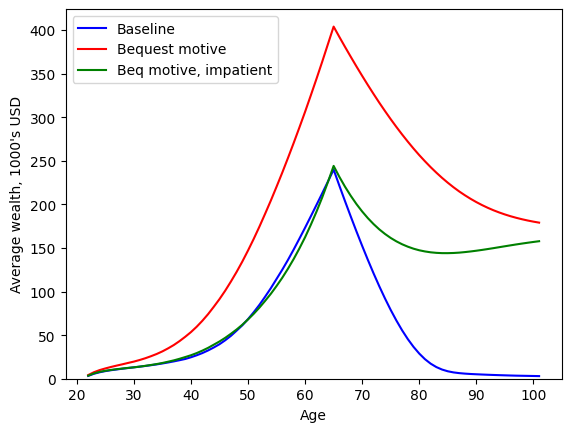

In [9]:
# Plot the three types' average wealth profiles
age_vec = np.arange(22, 102)
plt.plot(age_vec, A_base, "-b")
plt.plot(age_vec, A_bequest, "-r")
plt.plot(age_vec, A_impatient, "-g")
plt.legend(["Baseline", "Bequest motive", "Beq motive, impatient"], loc=2)
plt.xlabel("Age")
plt.ylabel("Average wealth, 1000's USD")
plt.ylim(0.0, None)
plt.show()

The addition of a bequest motive *vastly* increases wealth accumulation, even early in life. Even though the agents have little chance of dying *soon*, they foresee that they *will* want to hold significant wealth late in life, and thus need to accumulate more wealth early in order to finance their consumption in retirement *and* later retained wealth.

In order to get wealth at age 65 to (approximately) match the baseline level, agents with a bequest motive must be significantly more impatient. Even then, under these parameters, they will run down their wealth before *re-accumulating* it at very old ages. Notice that both the $\DiscFac = 0.96$ and $\DiscFac = 0.915$ types with a bequest motive seem to be approaching the same target wealth level in their late 90's. This is not a coincidence. As death becomes more and more likely, the discount factor becomes less and less relevant; only the bequest motive drives saving behavior when survival is unlikely to continue much longer.